# System rekomendacji win
### Porównanie modeli: NCF, Gradient Boosting, Random Forest, RP3β

## 1. Importy i konfiguracja

In [7]:
import sys
import os
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt

print(sys.executable)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

c:\Users\Filip\wine_pc\wine-recommender\.venv\Scripts\python.exe
Torch version: 2.10.0+cu126
CUDA available: True
GPU name: NVIDIA GeForce RTX 2060
Using device: cuda


## 2. Wczytanie i podział danych

In [8]:
df = pd.read_csv('data\\XWines_Slim_150K_ratings.csv')
df = df[["Rating", "UserID", "WineID", "Date"]]
df.sort_values("Date", ascending=True, inplace=True)
df.reset_index(drop=True, inplace=True)

split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

X_train = train_df[["UserID", "WineID", "Date"]]
y_train = train_df["Rating"]
X_test  = test_df[["UserID", "WineID", "Date"]].copy()
y_test  = test_df["Rating"]

print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

Train size: 120000, Test size: 30000


C:\Users\Filip\AppData\Local\Temp\ipykernel_4404\2572918404.py:1: DtypeWarning: Columns (0: Vintage) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data\\XWines_Slim_150K_ratings.csv')


## 3. Mapowanie użytkowników i win na indeksy

In [9]:
users    = X_train['UserID'].unique()
wines    = X_train['WineID'].unique()
user2_id = {u: i for i, u in enumerate(users)}
wine2_id = {w: i for i, w in enumerate(wines)}

X_train = X_train.copy()
X_train['user_idx'] = X_train['UserID'].map(user2_id)
X_train['wine_idx'] = X_train['WineID'].map(wine2_id)
X_train.dropna(inplace=True)
y_train = y_train.loc[X_train.index]

X_test['user_idx'] = X_test['UserID'].map(user2_id)
X_test['wine_idx'] = X_test['WineID'].map(wine2_id)

# usuwanie cold-start (użytkownicy/wina spoza train)
mask = X_test['user_idx'].notna() & X_test['wine_idx'].notna()
X_test_clean = X_test[mask].copy()
y_test_clean = y_test[mask].copy()

for col in ['user_idx', 'wine_idx']:
    X_train[col]      = X_train[col].astype(int)
    X_test_clean[col] = X_test_clean[col].astype(int)

num_users = len(user2_id)
num_wines = len(wine2_id)
print(f"Liczba użytkowników: {num_users}, Liczba win: {num_wines}")
print(f"Cold-start usunięto: {(~mask).sum()} rekordów")

Liczba użytkowników: 10357, Liczba win: 1000
Cold-start usunięto: 1800 rekordów


## 4. Konwersja do tensorów i DataLoader

In [10]:
X_user_train = torch.tensor(X_train['user_idx'].values, dtype=torch.long)
X_wine_train = torch.tensor(X_train['wine_idx'].values, dtype=torch.long)
y_train_t    = torch.tensor(y_train.values, dtype=torch.float32)

X_user_test = torch.tensor(X_test_clean['user_idx'].values, dtype=torch.long)
X_wine_test = torch.tensor(X_test_clean['wine_idx'].values, dtype=torch.long)
y_test_t    = torch.tensor(y_test_clean.values, dtype=torch.float32)

batch_size    = 2048
train_loader  = DataLoader(TensorDataset(X_user_train, X_wine_train, y_train_t),
                           batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=2)
test_loader   = DataLoader(TensorDataset(X_user_test, X_wine_test, y_test_t),
                           batch_size=batch_size, pin_memory=True, num_workers=2)

## 5. Funckje metryk

In [17]:
def calculate_regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

def precision_at_k(y_true, y_pred, k=10, threshold=4.0):
    sorted_indices = np.argsort(y_pred)[::-1][:k]
    return np.sum(y_true[sorted_indices] >= threshold) / k

def recall_at_k(y_true, y_pred, k=10, threshold=4.0):
    sorted_indices   = np.argsort(y_pred)[::-1][:k]
    total_relevant   = np.sum(y_true >= threshold)
    relevant_in_topk = np.sum(y_true[sorted_indices] >= threshold)
    return relevant_in_topk / total_relevant if total_relevant > 0 else 0

def ndcg_at_k(y_true, y_pred, k=10):
    def dcg_at_k(r, k):
        r = np.asarray(r, dtype=np.float64)[:k]
        return np.sum(r / np.log2(np.arange(2, r.size + 2))) if r.size else 0.
    sorted_indices = np.argsort(y_pred)[::-1][:k]
    ideal_indices  = np.argsort(y_true)[::-1][:k]
    ideal_dcg      = dcg_at_k(y_true[ideal_indices], k)
    return dcg_at_k(y_true[sorted_indices], k) / ideal_dcg if ideal_dcg > 0 else 0

def evaluate_ranking_global(model, df_train, df_test, user2_id, wine2_id,
                            device=None, k=10, n_neg=100):

    results = {'Precision@{}'.format(k): [], 
               'Recall@{}'.format(k): [], 
               'NDCG@{}'.format(k): []}

    all_items = np.array(list(wine2_id.values()))
    user_train_items = df_train.groupby('UserID')['WineID'].apply(set)

    for user_id, group in df_test.groupby('UserID'):

        if user_id not in user2_id:
            continue

        pos_items = group['WineID'].values
        pos_idx = [wine2_id[i] for i in pos_items if i in wine2_id]

        if len(pos_idx) == 0:
            continue

        # --- NEGATIVE SAMPLING ---
        seen_items = user_train_items.get(user_id, set())
        neg_candidates = [i for i in wine2_id if i not in seen_items]

        if len(neg_candidates) > n_neg:
            neg_items = np.random.choice(neg_candidates, n_neg, replace=False)
        else:
            neg_items = neg_candidates

        neg_idx = [wine2_id[i] for i in neg_items]

        # --- CANDIDATE SET ---
        candidates = np.array(pos_idx + neg_idx)

        user_idx = user2_id[user_id]

        # --- PREDYKCJA ---
        if isinstance(model, nn.Module):
            model.eval()
            with torch.no_grad():
                u = torch.tensor([user_idx]*len(candidates)).to(device)
                w = torch.tensor(candidates).to(device)
                scores = model(u, w).squeeze().cpu().numpy()
        else:
            X = np.column_stack([[user_idx]*len(candidates), candidates])
            scores = model.predict(X)

        # --- TRUE LABELS ---
        y_true = np.array([1]*len(pos_idx) + [0]*len(neg_idx))

        # --- METRYKI ---
        results[f'Precision@{k}'].append(precision_at_k(y_true, scores, k, threshold=0.5))
        results[f'Recall@{k}'].append(recall_at_k(y_true, scores, k, threshold=0.5))
        results[f'NDCG@{k}'].append(ndcg_at_k(y_true, scores, k))

    return {k: np.mean(v) for k, v in results.items()}

def calculate_coverage(model, user2_id, wine2_id, device, threshold=3.5):
    model.eval()
    recommended_wines = set()
    with torch.no_grad():
        sample_users = np.random.choice(list(user2_id.values()),
                                        min(100, len(user2_id)), replace=False)
        for user_idx in sample_users:
            users_tensor = torch.tensor([user_idx] * len(wine2_id), dtype=torch.long, device=device)
            wines_tensor = torch.tensor(list(wine2_id.values()), dtype=torch.long, device=device)
            predictions  = model(users_tensor, wines_tensor).squeeze().cpu().numpy()
            recommended_wines.update(np.where(predictions >= threshold)[0])
    return len(recommended_wines) / len(wine2_id)

def evaluate_model(model, test_loader, X_test_df, y_test_array, user2_id, wine2_id, device, model_name):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for user, wine, rating in test_loader:
            preds = model(user.to(device), wine.to(device)).squeeze().cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(rating.numpy())

    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)

    ranking_metrics = evaluate_ranking_global(
    model, train_df, test_df, user2_id, wine2_id, device, k=10
    )   

    all_metrics = {
        'Model': model_name,
        **calculate_regression_metrics(all_true, all_preds),
        **ranking_metrics
    }
    return all_metrics, all_preds

## 6. RP3β

In [38]:
from sklearn.preprocessing import normalize
def train_test_split_per_user(df, test_size=0.2, random_state=42):
    train_list, test_list = [], []
    for _, user_data in df.groupby('UserID'):
        if len(user_data) < 2:
            continue
        train_u, test_u = train_test_split(user_data, test_size=test_size, random_state=random_state)
        train_list.append(train_u)
        test_list.append(test_u)
    return pd.concat(train_list), pd.concat(test_list)

class RP3Beta:
    def __init__(self, beta=0.6, top_k=100):
        self.beta = beta
        self.top_k = top_k
        self.user_item_matrix = None
        self.S_final = None

    def fit(self, df, user_col='UserID', item_col='WineID', rating_col='Rating'):
        self.users = df[user_col].unique()
        self.items = df[item_col].unique()
        self.user2idx = {u: i for i, u in enumerate(self.users)}
        self.item2idx = {it: j for j, it in enumerate(self.items)}

        rows = df[user_col].map(self.user2idx).values
        cols = df[item_col].map(self.item2idx).values

        self.user_item_matrix = csr_matrix(
            (df[rating_col].values, (rows, cols)),
            shape=(len(self.users), len(self.items))
        )
        
        Piu = normalize(self.user_item_matrix.T, norm='l1', axis=1)
        Pui = normalize(self.user_item_matrix, norm='l1', axis=1)

        S = Piu @ Pui

        item_degrees = np.array(self.user_item_matrix.sum(axis=0)).flatten()
        
        # Obliczamy potęgę bezpiecznie (tylko dla wartości > 0)
        penalty = np.zeros_like(item_degrees, dtype=float)
        mask = item_degrees > 0
        penalty[mask] = np.power(item_degrees[mask], self.beta)
        
        # Tam gdzie stopień był 0 lub wynik to 0, ustawiamy 1 (żeby nie dzielić przez 0)
        penalty[penalty == 0] = 1.0
            
        # KROK 5: Skalowanie macierzy podobieństwa
        # Używamy multiply, bo S to macierz rzadka (sparse), 
        # a dzielenie przez wektor robimy jako mnożenie przez 1/penalty
        from scipy.sparse import diags
        inv_penalty_matrix = diags(1.0 / penalty)
        
        # S_final[i, j] = S[i, j] * (1 / penalty[j])
        self.S_final = S @ inv_penalty_matrix
        

    def get_scores(self, user_id, candidate_wine_ids=None):
        u_idx = self.user2idx.get(user_id)
        if u_idx is None:
            return None, []

        user_profile = self.user_item_matrix[u_idx]
        scores_full = (user_profile @ self.S_final).toarray().flatten()

        if candidate_wine_ids is not None:
            result_scores = []
            valid_mask = []
            for c in candidate_wine_ids:
                if c in self.item2idx:
                    result_scores.append(scores_full[self.item2idx[c]])
                    valid_mask.append(True)
                else:
                    valid_mask.append(False)
            return np.array(result_scores), valid_mask  # zwracamy maskę!
        
        return scores_full, None


    def recommend(self, user_id, top_n=10):
            u_idx = self.user2idx.get(user_id)
            if u_idx is None: return []
            
            scores, _ = self.get_scores(user_id)
            # Zerujemy wina, które użytkownik już ocenił
            user_already_rated = self.user_item_matrix[u_idx].indices
            scores[user_already_rated] = -np.inf
            
            top_indices = np.argsort(scores)[::-1][:top_n]
            return [(self.items[i], scores[i]) for i in top_indices]
    
    def evaluate_ranking_global_xgb_emb(model_xgb, model_ncf, train_df, test_df, user2_id, wine2_id, device, k=10):
        precisions, recalls, ndcgs = [], [], []

        test_grouped = test_df.groupby('UserID')['WineID'].apply(set)

        for user_id, true_items in test_grouped.items():
            if user_id not in user2_id:
                continue

            user_idx = user2_id[user_id]

            # wszystkie wina
            all_items = list(wine2_id.keys())
            all_indices = list(wine2_id.values())

            # --- EMBEDDINGI ---
            model_ncf.eval()
            with torch.no_grad():
                u_tensor = torch.tensor([user_idx]*len(all_indices)).to(device)
                w_tensor = torch.tensor(all_indices).to(device)

                u_emb = model_ncf.user_embedding(u_tensor)
                w_emb = model_ncf.wine_embedding(w_tensor)

                X_emb = torch.cat([u_emb, w_emb], dim=1).cpu().numpy()

            scores = model_xgb.predict(X_emb)

            # top-k
            top_k_idx = np.argsort(scores)[::-1][:k]
            recs = [all_items[i] for i in top_k_idx]

            hits = len(set(recs) & true_items)

            precisions.append(hits / k)
            recalls.append(hits / len(true_items) if len(true_items) > 0 else 0)

            relevance = [1 if item in true_items else 0 for item in recs]
            ndcgs.append(ndcg_at_k(np.array(relevance), np.array(relevance), k))

        return {
            f'Precision@{k}': np.mean(precisions),
            f'Recall@{k}': np.mean(recalls),
            f'NDCG@{k}': np.mean(ndcgs)
        }



In [13]:
# def evaluate_rp3_full(model, test_df, k=10):
#     precisions, recalls, hits = [], [], []
    
#     # Grupujemy wina, które użytkownik faktycznie ocenił w przyszłości (test)
#     test_grouped = test_df.groupby('UserID')['WineID'].apply(set)
    
#     for user_id, true_wines in test_grouped.items():
#         if user_id not in model.user2idx:
#             continue
            
#         # Pobieramy Top-K rekomendacji (same ID win)
#         recs = [item for item, _ in model.recommend(user_id, top_n=k)]
#         recs_set = set(recs)
        
#         # Obliczamy trafienia (część wspólna)
#         intersects = len(recs_set & true_wines)
        
#         precisions.append(intersects / k)
#         recalls.append(intersects / len(true_wines) if len(true_wines) > 0 else 0)
#         hits.append(1.0 if intersects > 0 else 0.0)
        
#     return {
#         f"Precision@{k}": np.mean(precisions),
#         f"Recall@{k}": np.mean(recalls),
#         f"HitRate@{k}": np.mean(hits)
#     }

# # --- URUCHOMIENIE ---

# # 1. Używamy Twojego chronologicznego splitu (spójność z XGBoost!)
# # train_df_rp3, test_df_rp3 = train_df, test_df 

# rp3 = RP3Beta(beta=0.6)
# rp3.fit(train_df) # Zakładam, że train_df to Twój 80% split po dacie

# print("\nWyniki RP3β):")
# results = evaluate_rp3_full(rp3, test_df, k=10)
# for metric, value in results.items():
#     print(f"  {metric}: {value:.4f}")

In [20]:
def evaluate_rp3_global(model, train_df, test_df, k=10):

    precisions, recalls, ndcgs = [], [], []

    train_items = train_df.groupby('UserID')['WineID'].apply(set)
    test_items  = test_df.groupby('UserID')['WineID'].apply(set)

    for user in test_items.index:

        if user not in model.user2idx:
            continue

        true_items = test_items[user]

        recs = [i for i, _ in model.recommend(user, top_n=k)]

        hits = len(set(recs) & true_items)

        precisions.append(hits / k)
        recalls.append(hits / len(true_items))

        # ndcg
        relevance = np.array([1 if i in true_items else 0 for i in recs])
        scores = np.arange(len(relevance))[::-1]  # ranking: top → bottom

        ndcgs.append(ndcg_at_k(relevance, scores, k))

    return {
        'Precision@10': np.mean(precisions),
        'Recall@10': np.mean(recalls),
        'NDCG@10': np.mean(ndcgs)
    }

rp3 = RP3Beta(beta=0.3)
rp3.fit(train_df) # Zakładam, że train_df to Twój 80% split po dacie
# Uruchamiamy 'lokalną' ewaluację dla RP3beta
metrics_rp3_global = evaluate_rp3_global(rp3, train_df, test_df, k=10)

print("\nWyniki RP3β", metrics_rp3_global)


Wyniki RP3β {'Precision@10': np.float64(0.06584699453551912), 'Recall@10': np.float64(0.19588333451150222), 'NDCG@10': np.float64(0.2470569166434098)}


## 7. Model NCF (Neural Collaborative Filtering)

In [21]:
class NCF(nn.Module):
    def __init__(self, num_users, num_wines, embedding_dim=80):
        super(NCF, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.wine_embedding = nn.Embedding(num_wines, embedding_dim)
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.wine_embedding.weight, std=0.01)

        self.layer1  = nn.Linear(embedding_dim * 2, 128)
        self.bn1     = nn.BatchNorm1d(128)
        self.layer2  = nn.Linear(128, 64)
        self.bn2     = nn.BatchNorm1d(64)
        self.layer3  = nn.Linear(64, 1)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, user, wine):
        user_emb = self.user_embedding(user)
        wine_emb = self.wine_embedding(wine)
        x = torch.cat([user_emb, wine_emb], dim=1)
        
        x = self.relu(self.bn1(self.layer1(x)))
        x = self.dropout(x)
        
        x = self.relu(self.bn2(self.layer2(x)))
        x = self.dropout(x)
        
        x = self.layer3(x)
        return x

model_ncf = NCF(num_users, num_wines, embedding_dim=50).to(device)
print(model_ncf)

NCF(
  (user_embedding): Embedding(10357, 50)
  (wine_embedding): Embedding(1000, 50)
  (layer1): Linear(in_features=100, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)


In [22]:
criterion_ncf = nn.MSELoss()
optimizer_ncf = optim.Adam(model_ncf.parameters(), lr=0.003, weight_decay=1e-4)
scheduler_ncf = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ncf, mode='min', factor=0.5, patience=2)

best_loss_ncf, patience_ncf, counter_ncf = float('inf'), 5, 0

for epoch in range(20):
    # --- FAZA UCZENIA (Tylko Train) ---
    model_ncf.train()
    train_loss = 0
    for user, wine, rating in train_loader:
        user, wine, rating = user.to(device), wine.to(device), rating.to(device)
        optimizer_ncf.zero_grad()
        loss = criterion_ncf(model_ncf(user, wine).squeeze(), rating)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ncf.parameters(), max_norm=1.0)
        optimizer_ncf.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # --- FAZA WALIDACJI (Tylko Test) ---
    model_ncf.eval()
    test_loss = 0
    with torch.no_grad():
        for user, wine, rating in test_loader: # <--- TU WRACA TEST_LOADER
            user, wine, rating = user.to(device), wine.to(device), rating.to(device)
            test_loss += criterion_ncf(model_ncf(user, wine).squeeze(), rating).item()
    test_loss /= len(test_loader) # <--- DZIELIMY PRZEZ TEST_LOADER

    # Dalej scheduler i zapisywanie modelu...
    scheduler_ncf.step(test_loss)
    print(f"Epoch {epoch+1}/20  Train: {train_loss:.4f}  Val: {test_loss:.4f}")

    if test_loss < best_loss_ncf:
        best_loss_ncf = test_loss
        counter_ncf   = 0
        torch.save(model_ncf.state_dict(), "best_model_ncf.pt")
        print(f"  ✓ New best model saved! (Test Loss: {test_loss:.4f})")
    else:
        counter_ncf += 1

    if counter_ncf >= patience_ncf:
        print(f"Early stopping triggered on epoch {epoch+1}")
        break

model_ncf.load_state_dict(torch.load("best_model_ncf.pt"))
print(f"\n Best NCF model loaded with Test Loss: {best_loss_ncf:.4f}")

Epoch 1/20  Train: 3.4008  Val: 0.3581
  ✓ New best model saved! (Test Loss: 0.3581)
Epoch 2/20  Train: 0.5253  Val: 0.2752
  ✓ New best model saved! (Test Loss: 0.2752)
Epoch 3/20  Train: 0.4171  Val: 0.2537
  ✓ New best model saved! (Test Loss: 0.2537)
Epoch 4/20  Train: 0.3662  Val: 0.2297
  ✓ New best model saved! (Test Loss: 0.2297)
Epoch 5/20  Train: 0.3334  Val: 0.2332
Epoch 6/20  Train: 0.3032  Val: 0.2380
Epoch 7/20  Train: 0.2795  Val: 0.2469
Epoch 8/20  Train: 0.2508  Val: 0.2529
Epoch 9/20  Train: 0.2354  Val: 0.2382
Early stopping triggered on epoch 9

 Best NCF model loaded with Test Loss: 0.2297


In [23]:
metrics_ncf, preds_ncf = evaluate_model(
    model_ncf, test_loader, X_test_clean, y_test_clean.values,
    user2_id, wine2_id, device, "NCF"
)
print("NCF Metrics:", metrics_ncf)

NCF Metrics: {'Model': 'NCF', 'RMSE': np.float64(0.4793870270624106), 'MAE': 0.36473676562309265, 'R2': 0.3070680499076843, 'Precision@10': np.float64(0.0652049180327869), 'Recall@10': np.float64(0.1813206826008014), 'NDCG@10': np.float64(0.12375986293345266)}


## 8. Model Gradient Boosting 

In [25]:
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor

# 1. Przygotowanie danych surowych (tylko ID użytkownika i ID wina)
X_train_raw = X_train[['user_idx', 'wine_idx']]
X_test_raw = X_test_clean[['user_idx', 'wine_idx']]

print("--- Trening modeli na surowych danych (Raw IDs) ---")

# --- MODEL A: XGBoost (Raw) ---
model_xgb_raw = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    objective='reg:squarederror'
)

print("Uczenie XGBoost (Raw)...")
model_xgb_raw.fit(X_train_raw, y_train)
preds_xgb_raw = model_xgb_raw.predict(X_test_raw)

metrics_xgb_raw = {
    'Model': 'XGBoost Raw',
    **calculate_regression_metrics(y_test_clean.values, preds_xgb_raw),
    **evaluate_ranking_global(model_xgb_raw, train_df, test_df, user2_id, wine2_id, device, k=10)
}

print("XGBoost (Raw) Metrics:", metrics_xgb_raw)

--- Trening modeli na surowych danych (Raw IDs) ---
Uczenie XGBoost (Raw)...
XGBoost (Raw) Metrics: {'Model': 'XGBoost Raw', 'RMSE': np.float64(0.5201214960702686), 'MAE': 0.3972572046898781, 'R2': 0.18430527606072944, 'Precision@10': np.float64(0.0978551912568306), 'Recall@10': np.float64(0.2734740359398338), 'NDCG@10': np.float64(0.19512947811379944)}


## 9. Model Random Forest

In [26]:
# --- MODEL B: Random Forest (Raw) ---
model_rf_raw = RandomForestRegressor(
    n_estimators=50, # Mniej drzew, żeby szybciej poszło (na surowych danych i tak cudów nie będzie)
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

print("Uczenie Random Forest (Raw)...")
model_rf_raw.fit(X_train_raw, y_train)
preds_rf_raw = model_rf_raw.predict(X_test_raw)

metrics_rf_raw = {
    'Model': 'Random Forest Raw',
    **calculate_regression_metrics(y_test_clean.values, preds_rf_raw),
    **evaluate_ranking_global(model_rf_raw, train_df, test_df, user2_id, wine2_id, device, k=10)
}
print("Random Forest (Raw) Metrics:", metrics_rf_raw)

Uczenie Random Forest (Raw)...


c:\Users\Filip\wine_pc\wine-recommender\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Filip\wine_pc\wine-recommender\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Filip\wine_pc\wine-recommender\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Filip\wine_pc\wine-recommender\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Filip\wine_pc\wine-recommender\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X doe

Random Forest (Raw) Metrics: {'Model': 'Random Forest Raw', 'RMSE': np.float64(0.5235191205088413), 'MAE': 0.40591772526864467, 'R2': 0.173613634474153, 'Precision@10': np.float64(0.11392076502732242), 'Recall@10': np.float64(0.31993409114843824), 'NDCG@10': np.float64(0.2178569343926875)}


c:\Users\Filip\wine_pc\wine-recommender\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Filip\wine_pc\wine-recommender\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## 10. Model Gradient Boosting + NCF Embeddings

In [27]:
def extract_embeddings_for_xgb(model, loader, device):
    model.eval()
    all_x = []
    all_y = []
    with torch.no_grad():
        for user, wine, rating in loader:
            user, wine = user.to(device), wine.to(device)
            # Wyciągamy wektory i łączymy je (concat)
            u_emb = model.user_embedding(user)
            w_emb = model.wine_embedding(wine)
            combined = torch.cat([u_emb, w_emb], dim=1)
            
            all_x.append(combined.cpu().numpy())
            all_y.append(rating.numpy())
    return np.concatenate(all_x), np.concatenate(all_y)

# Przygotowujemy dane (używamy warstw embedding z modelu NCF)
print("Data for XGBoost preparation")
X_train_xgb, y_train_xgb = extract_embeddings_for_xgb(model_ncf, train_loader, device)
X_test_xgb, y_test_xgb   = extract_embeddings_for_xgb(model_ncf, test_loader, device)

Data for XGBoost preparation


In [28]:


# Konfiguracja modelu
# tree_method='hist' i device='cuda' zapewniają szybkość na GPU
model_xgb_real = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    objective='reg:squarederror'
)

print("Training XGBoost with NCF embeddings")
model_xgb_real.fit(X_train_xgb, y_train_xgb)

# Predykcja dla całego zbioru testowego dad
preds_gb = model_xgb_real.predict(X_test_xgb)

Training XGBoost with NCF embeddings


In [39]:
# Obliczamy metryki używając Twoich istniejących funkcji
metrics_gb = {
    'Model': 'Gradient Boosting + NCF embeddings',
    **calculate_regression_metrics(y_test_xgb, preds_gb),

    **evaluate_ranking_global_xgb_emb(
        model_xgb_real, model_ncf, train_df, test_df,
        user2_id, wine2_id, device, k=5
    ),

    **evaluate_ranking_global_xgb_emb(
        model_xgb_real, model_ncf, train_df, test_df,
        user2_id, wine2_id, device, k=10
    ),

    'Coverage': 0.0
}

print("XGBoost Metrics:", metrics_gb)

NameError: name 'evaluate_ranking_global_xgb_emb' is not defined

## 11. Model Random Forest + NCF Embeddings

In [33]:
print("Training Random Forest with NCF embeddings")

# Konfiguracja prawdziwego Random Forest
model_rf_real = RandomForestRegressor(
    n_estimators=100,      # Liczba drzew
    max_depth=15,          # Ograniczenie głębokości (zapobiega przeuczeniu)
    min_samples_leaf=5,    # Minimum próbek w liściu
    random_state=42,       # Dla powtarzalności wyników
    n_jobs=-1              # Używa wszystkich rdzeni procesora (bardzo ważne!)
)

# Trening na wyciągniętych wektorach (jak w XGBoost)
model_rf_real.fit(X_train_xgb, y_train_xgb)

# Predykcja
preds_rf = model_rf_real.predict(X_test_xgb)

# Obliczenie metryk
metrics_rf = {
    'Model': 'Random Forest + NCF embeddings',
    **calculate_regression_metrics(y_test_xgb, preds_rf),
    **evaluate_ranking_global(model_rf_real, train_df, test_df, user2_id, wine2_id, device, k=5),
    **evaluate_ranking_global(model_rf_real, train_df, test_df, user2_id, wine2_id, device, k=10),
    'Coverage': 0.0 # Obliczenie coverage dla modeli nie-PyTorchowych wymaga innej logiki
}

print("Random Forest Metrics:", metrics_rf)

Training Random Forest with NCF embeddings


ValueError: X has 2 features, but RandomForestRegressor is expecting 100 features as input.

## 12. Podsumowanie wyników

In [36]:
import pandas as pd

# Zbieramy wszystkie wyniki w jedną listę
all_results = [
    metrics_xgb_raw,    # XGBoost na surowych ID
    metrics_rf_raw,     # Random Forest na surowych ID
    metrics_ncf,        # Czysty NCF (Deep Learning)
    metrics_gb,         # Hybryda: XGBoost + NCF Embs
    metrics_rf,         # Hybryda: RF + NCF Embs
    metrics_rp3_global  # RP3beta (Lokalny ranking)
]

# Tworzymy DataFrame
final_table = pd.DataFrame(all_results)


# Zaokrąglamy wyniki dla lepszej czytelności
final_table = final_table.round(4)


# Wyświetlamy tabelę posortowaną po NDCG (najlepsza metryka jakości rankingu)
print("FINALNE ZESTAWIENIE MODELI")
display(final_table.sort_values(by='NDCG@10', ascending=False))

NameError: name 'metrics_gb' is not defined

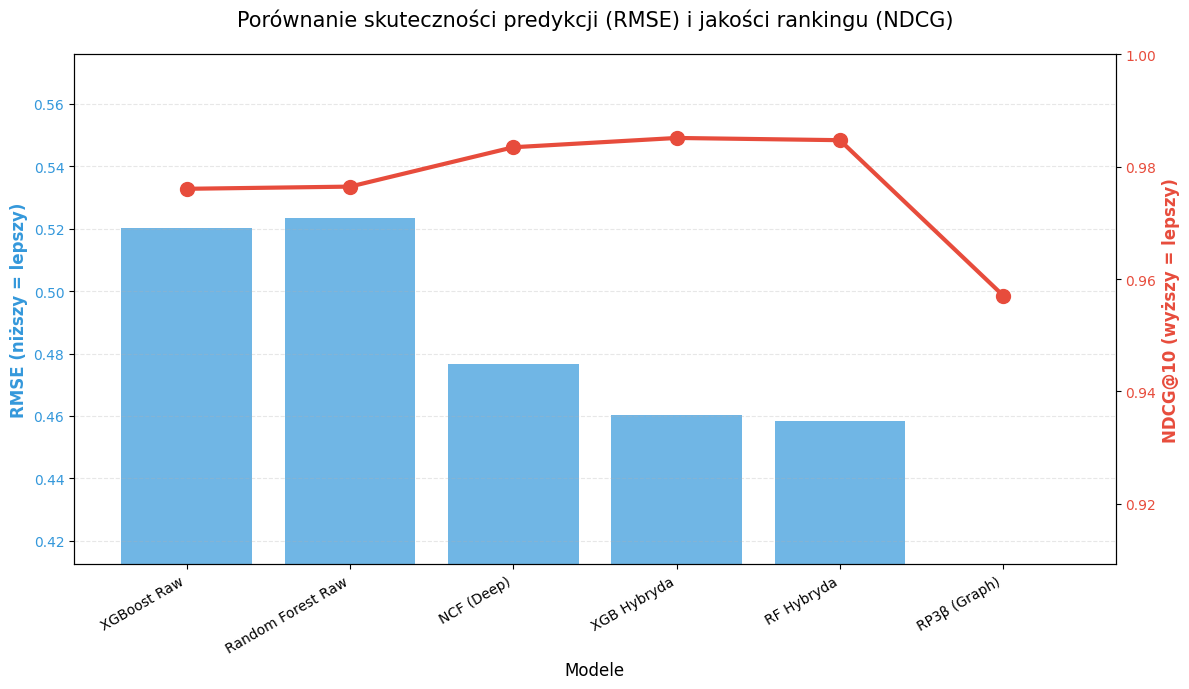

In [ ]:


# 2. Tworzenie DataFrame
df_results = pd.DataFrame(all_results)

# 3. Bezpieczne mapowanie nazw
# Jeśli nazwa z 'Model' nie znajdzie się w słowniku, zostawi oryginalną nazwę
name_map = {
    'Gradient Boosting (XGBoost)': 'XGB Hybryda',
    'Random Forest (Sklearn)': 'RF Hybryda',
    'NCF': 'NCF (Deep)',
    'Random Forest (Raw ID)': 'RF Raw',
    'XGBoost (Raw ID)': 'XGB Raw',
    'RP3β (Graph)': 'RP3β (Graph)'
}
df_results['Model_Short'] = df_results['Model'].map(name_map).fillna(df_results['Model'])

# --- KLUCZOWA POPRAWKA ---
# Matplotlib nie lubi floatów (np. NaN) tam, gdzie spodziewa się etykiet tekstowych
df_results['Model_Short'] = df_results['Model_Short'].astype(str)
# -------------------------

fig, ax1 = plt.subplots(figsize=(12, 7))

# Oś 1: RMSE (Słupki)
color1 = '#3498db'
ax1.set_xlabel('Modele', fontsize=12)
ax1.set_ylabel('RMSE (niższy = lepszy)', color=color1, fontsize=12, fontweight='bold')

# Rysujemy słupki - używamy .fillna(0), żeby bar() nie wywalił błędu na RP3beta
bars = ax1.bar(df_results['Model_Short'], df_results['RMSE'].fillna(0), color=color1, alpha=0.7, label='RMSE')
ax1.tick_params(axis='y', labelcolor=color1)

# Ustawienie limitów osi Y tylko dla RMSE > 0
valid_rmse = df_results['RMSE'].dropna()
if not valid_rmse.empty:
    ax1.set_ylim(valid_rmse.min() * 0.9, valid_rmse.max() * 1.1)

# Oś 2: NDCG@10 (Linia)
ax2 = ax1.twinx()
color2 = '#e74c3c'
ax2.set_ylabel('NDCG@10 (wyższy = lepszy)', color=color2, fontsize=12, fontweight='bold')
ax2.plot(df_results['Model_Short'], df_results['NDCG@10'], color=color2, marker='o', markersize=10, linewidth=3, label='NDCG@10')
ax2.tick_params(axis='y', labelcolor=color2)

# Dynamiczny limit dla NDCG
ax2.set_ylim(df_results['NDCG@10'].min() * 0.95, 1.0)

plt.title('Porównanie skuteczności predykcji (RMSE) i jakości rankingu (NDCG)', fontsize=15, pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
plt.setp(ax1.get_xticklabels(), rotation=30, ha='right')

fig.tight_layout()
plt.show()

In [ ]:
def get_hybrid_recommendations(user_id, model_ncf, model_xgb, df_all, user2_id, wine2_id, device, top_n=5):
    """
    Generuje konkretne rekomendacje dla wybranego użytkownika, 
    używając hybrydy (NCF Embeddings + XGBoost).
    """
    # 1. Historia użytkownika (co pił i jak ocenił)
    user_history = df_all[df_all['UserID'] == user_id].sort_values(by='Rating', ascending=False).head(10)
    
    # 2. Wybór kandydatów (wina, których NIE pił, a są w słowniku wine2_id)
    watched_wines = set(df_all[df_all['UserID'] == user_id]['WineID'])
    all_available_wines = [w for w in wine2_id.keys() if w not in watched_wines]
    
    # Ograniczamy liczbę kandydatów do 1000 losowych, żeby nie czekać wiecznie
    if len(all_available_wines) > 1000:
        import random
        all_available_wines = random.sample(all_available_wines, 1000)
    
    # 3. Przygotowanie cech (Embeddingów) dla kandydatów
    u_idx = user2_id[user_id]
    w_indices = [wine2_id[w] for w in all_available_wines]
    
    model_ncf.eval()
    with torch.no_grad():
        u_tensor = torch.tensor([u_idx] * len(w_indices)).to(device)
        w_tensor = torch.tensor(w_indices).to(device)
        
        u_emb = model_ncf.user_embedding(u_tensor)
        w_emb = model_ncf.wine_embedding(w_tensor)
        combined_features = torch.cat([u_emb, w_emb], dim=1).cpu().numpy()
    
    # 4. Predykcja przez XGBoost
    preds = model_xgb.predict(combined_features)
    
    # 5. Wyniki
    results = pd.DataFrame({
        'WineID': all_available_wines,
        'PredictedRating': preds
    }).sort_values(by='PredictedRating', ascending=False).head(top_n)
    
    return user_history[['WineID', 'Rating', 'Date']], results

# --- WYWOŁANIE PRZYKŁADU ---
example_user = train_df['UserID'].iloc[50] # Wybieramy kogoś z bazy
history, recs = get_hybrid_recommendations(example_user, model_ncf, model_xgb_real, df, user2_id, wine2_id, device)

print(f"\n--- CASE STUDY DLA UŻYTKOWNIKA: {example_user} ---")
print("Ostatnio ocenione wina (Ground Truth):")
print(history)
print("\nSugerowane wina (Hybrid Recommendations):")
print(recs)


--- CASE STUDY DLA UŻYTKOWNIKA: 1197665 ---
Ostatnio ocenione wina (Ground Truth):
        WineID  Rating                 Date
4071    135871     4.5  2014-01-16 20:04:48
131233  113050     4.5  2021-02-17 20:38:42
44348   179084     4.0  2017-04-12 07:30:34
50      136522     4.0  2012-09-09 10:58:31
57215   179044     4.0  2017-12-18 14:58:45
66126   106688     4.0  2018-05-26 15:06:18
124209  112185     4.0  2020-11-02 21:31:51
96648   171001     4.0  2019-09-10 11:10:31
48773   155618     4.0  2017-07-06 11:34:33
33052   101660     4.0  2016-07-31 18:40:54

Sugerowane wina (Hybrid Recommendations):
     WineID  PredictedRating
17   174184         4.768690
4    111395         4.721039
112  112084         4.671326
351  179855         4.669662
5    111415         4.640338


## Serendipity Recommendations

In [ ]:
def get_surprise_recommendations(user_id, model_ncf, model_xgb, df_all, user2_id, wine2_id, device, top_n=5, surprise_factor=0.3):
    """
    Generuje rekomendacje z 'zasadą niespodzianki' (Serendipity).
    surprise_factor: 0.0 (tylko predykcja) do 1.0 (silne promowanie niszowych win)
    """
    # 1. Obliczamy popularność każdego wina (ile razy występuje w całym df)
    wine_counts = df_all['WineID'].value_counts()
    max_counts = wine_counts.max()
    
    # 2. Pobieramy szerszą listę kandydatów (np. 50 najlepszych wg modelu)
    # Wykorzystujemy Twoją istniejącą logikę, ale prosimy o 50 wyników
    _, candidates = get_hybrid_recommendations(user_id, model_ncf, model_xgb, df_all, user2_id, wine2_id, device, top_n=50)
    
    # 3. Obliczamy 'Novelty Score' (im rzadsze wino, tym wyższy score)
    # Popularność normalizujemy do 0-1 i odwracamy
    candidates['Popularity'] = candidates['WineID'].map(wine_counts) / max_counts
    candidates['Novelty'] = 1 - candidates['Popularity']
    
    # 4. Łączymy Predykcję z Nowością (Serendipity Score)
    # Skalujemy PredictedRating do zakresu 0-1 dla równej walki z Novelty
    min_p, max_p = candidates['PredictedRating'].min(), candidates['PredictedRating'].max()
    candidates['Score_Norm'] = (candidates['PredictedRating'] - min_p) / (max_p - min_p + 1e-6)
    
    # Finalny wzór: balans między dopasowaniem a niespodzianką
    candidates['Serendipity_Score'] = (
        (1 - surprise_factor) * candidates['Score_Norm'] + 
        surprise_factor * candidates['Novelty']
    )
    
    # 5. Wybieramy finalne Top N
    surprise_recs = candidates.sort_values(by='Serendipity_Score', ascending=False).head(top_n)
    
    return surprise_recs[['WineID', 'PredictedRating', 'Popularity', 'Serendipity_Score']]

# --- TEST ---
surprise_recs = get_surprise_recommendations(example_user, model_ncf, model_xgb_real, df, user2_id, wine2_id, device, surprise_factor=0.4)
print("\n--- REKOMENDACJE Z ELEMENTEM NIESPODZIANKI (SERENDIPITY) ---")
print(surprise_recs)


--- REKOMENDACJE Z ELEMENTEM NIESPODZIANKI (SERENDIPITY) ---
     WineID  PredictedRating  Popularity  Serendipity_Score
351  179855         4.669662    0.099351           0.847523
112  112084         4.671326    0.135065           0.835131
17   174184         4.768690    0.420779           0.831687
764  182169         4.615001    0.011688           0.820360
238  112664         4.623520    0.098701           0.795253


In [ ]:
preds_ncf.min()

np.float32(1.615846)